# Data Processing, EDA, and Early Probe

# Loading Data

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import json
with open("../data/DEC.json") as f:
    dec = json.load(f)
print(type(dec), len(dec))
first = dec[0] if isinstance(dec, list) else dec[next(iter(dec))]
print(first.keys() if isinstance(first, dict) else type(first))

<class 'dict'> 1800
<class 'str'>


In [3]:
# what do the keys look like
keys = list(dec.keys())
print(keys[:10])

# how long is a transcript, and how does it start
k = keys[0]
print(len(dec[k]), "characters")
print(dec[k][:300])

# what's in the embeddings folder
import os
for root, dirs, files in os.walk("../data/Embeddings"):
    for f in files:
        path = os.path.join(root, f)
        print(path, round(os.path.getsize(path) / 1e6, 1), "MB")

['AAPL_2019_Q1_20190129.txt', 'AAPL_2019_Q2_20190430.txt', 'AAPL_2019_Q3_20190730.txt', 'AAPL_2019_Q4_20191030.txt', 'AAPL_2020_Q1_20200128.txt', 'AAPL_2020_Q2_20200430.txt', 'AAPL_2020_Q3_20200730.txt', 'AAPL_2020_Q4_20201029.txt', 'AAPL_2021_Q1_20210127.txt', 'AAPL_2021_Q2_20210428.txt']
46319 characters
Operator: Good day and welcome to the Apple Incorporated First Quarter Fiscal Year 2019 Earnings Conference Call. Today's call is being recorded. At this time for opening remarks and introductions, I would like to turn the call over to Nancy Paxton, Senior Director of Investor Relations. Please, go 
../data/Embeddings/.DS_Store 0.0 MB
../data/Embeddings/openai/DEC2RandomTicker.npz 44.3 MB
../data/Embeddings/openai/DEC.npz 26.7 MB
../data/Embeddings/openai/DECRandomAll.npz 44.3 MB


In [4]:


# what arrays are stored and what are the shapes of the embeddings
for name in ["DEC", "DEC2RandomTicker", "DECRandomAll"]:
    npz = np.load(f"../data/Embeddings/openai/{name}.npz", allow_pickle=True)
    print(name)
    for k in npz.files:
        arr = npz[k]
        print("  ", k, arr.shape, arr.dtype)
        if arr.ndim == 1:
            print("     first entries:", arr[:3])

# DEC.json: what do the keys look like?
keys = list(dec.keys())
print(keys[:10])
k = keys[0]
print(len(dec[k]), "characters")
print(dec[k][:300])

DEC
   embeddings (1800, 3072) float64
   ids (1800,) <U22
     first entries: ['AAPL_2019_Q1_20190129' 'AAPL_2019_Q2_20190430' 'AAPL_2019_Q3_20190730']
DEC2RandomTicker
   embeddings (1800, 3072) float64
   ids (1800,) object
     first entries: ['AAPL_2019_Q1_20190129' 'AAPL_2019_Q2_20190430' 'AAPL_2019_Q3_20190730']
DECRandomAll
   embeddings (1800, 3072) float64
   ids (1800,) object
     first entries: ['AAPL_2019_Q1_20190129' 'AAPL_2019_Q2_20190430' 'AAPL_2019_Q3_20190730']
['AAPL_2019_Q1_20190129.txt', 'AAPL_2019_Q2_20190430.txt', 'AAPL_2019_Q3_20190730.txt', 'AAPL_2019_Q4_20191030.txt', 'AAPL_2020_Q1_20200128.txt', 'AAPL_2020_Q2_20200430.txt', 'AAPL_2020_Q3_20200730.txt', 'AAPL_2020_Q4_20201029.txt', 'AAPL_2021_Q1_20210127.txt', 'AAPL_2021_Q2_20210428.txt']
46319 characters
Operator: Good day and welcome to the Apple Incorporated First Quarter Fiscal Year 2019 Earnings Conference Call. Today's call is being recorded. At this time for opening remarks and introductions, I would l

In [5]:

df = pd.read_csv("../data/DEC.csv")
print(df.shape)

# which columns hold volatility labels
vol_cols = [c for c in df.columns if c.startswith("lv")]
print(len(vol_cols), vol_cols[:12], "...", vol_cols[-6:])

# timing flag and coverage
print(df["beforeAfterMarket"].value_counts())
print(df["sector"].value_counts())

# do the ids match DEC.json?
json_ids = {k.replace(".txt", "") for k in dec.keys()}
print("ids match:", set(df["id"]) == json_ids)

# one row's label columns, to see what they contain
print(df.loc[0, [c for c in vol_cols if "future" in c]].head(10))

(1800, 251)
147 ['lv3_past_1', 'lv7_past_1', 'lv15_past_1', 'lv30_past_1', 'lv3_past_2', 'lv7_past_2', 'lv15_past_2', 'lv30_past_2', 'lv3_past_3', 'lv7_past_3', 'lv15_past_3', 'lv30_past_3'] ... ['lv30_future_25', 'lv30_future_26', 'lv30_future_27', 'lv30_future_28', 'lv30_future_29', 'lv30_future_30']
beforeAfterMarket
BeforeMarket    1255
AfterMarket      545
Name: count, dtype: int64
sector
Healthcare                180
Industrial                180
Real Estate               180
Financial Services        180
Consumer Discretionary    180
Technology                160
Comsumer Staples          160
Communication Services    160
Utility                   140
Basic Materials           140
Energy                    140
Name: count, dtype: int64
ids match: True
lv3_future_1   -3.301153
lv3_future_2   -3.389354
lv3_future_3   -3.489151
lv7_future_1   -3.522415
lv7_future_2   -3.616587
lv7_future_3   -3.609831
lv7_future_4   -3.639136
lv7_future_5   -3.671393
lv7_future_6   -3.714979
lv7_fu

# Label Verification

In [6]:

row = df.loc[0]
fut = np.array([row[f"p_future_{i}"] for i in range(1, 31)])
past = np.array([row[f"p_past_{i}"] for i in range(1, 24)])

def logvol(r, how):
    if how == "std_n":    return np.log(np.std(r))           # divide by n
    if how == "std_n-1":  return np.log(np.std(r, ddof=1))   # divide by n-1
    if how == "no_norm":  return np.log(np.sqrt(((r - r.mean())**2).sum()))

print("stored lv3_future_1..3:", [round(row[f"lv3_future_{k}"], 4) for k in (1, 2, 3)])
for how in ["std_n", "std_n-1", "no_norm"]:
    starting = [logvol(fut[k-1:k+2], how) for k in (1, 2, 3)]      # window starts at day k
    print(how, "window starting at k:", np.round(starting, 4))

# and a window ending at day k (mixes pre- and post-call days)
seq = np.concatenate([past[:2][::-1], fut])   # past_2, past_1, future_1, ...
for how in ["std_n", "std_n-1", "no_norm"]:
    ending = [logvol(seq[k-1:k+2], how) for k in (1, 2, 3)]
    print(how, "window ending at k:", np.round(ending, 4))

stored lv3_future_1..3: [np.float64(-3.3012), np.float64(-3.3894), np.float64(-3.4892)]
std_n window starting at k: [-3.4892 -4.4312 -4.4681]
std_n-1 window starting at k: [-3.2864 -4.2285 -4.2654]
no_norm window starting at k: [-2.9398 -3.8819 -3.9188]
std_n window ending at k: [-3.3012 -3.3894 -3.4892]
std_n-1 window ending at k: [-3.0984 -3.1866 -3.2864]
no_norm window ending at k: [-2.7518 -2.84   -2.9398]


- p_past_1 is the day just before the call
- Formula: log of the standard deviation with division by n (the daily return scale)
- lv3_future_1 is not the target. It's the 3 day window ending on day 1 so it mixes two pre call days with one post call day. The fully post call 3 day window is lv_3_futures_3

# Target and Company Baseline

In [7]:
# clean the sector typo
df["sector"] = df["sector"].replace("Comsumer Staples", "Consumer Staples")

# target: 3-day post-earnings log volatility (days 1-3 after the call)
df["y3"] = df["lv3_future_3"]

# order each company's calls in time
df["day_earnings"] = pd.to_datetime(df["day_earnings"])
df = df.sort_values(["ticker", "day_earnings"]).reset_index(drop=True)

# company baseline: mean of that company's PAST post-earnings vol only
# shift(1) excludes the current call, so there's no look-ahead
df["base3"] = (df.groupby("ticker")["y3"]
                 .transform(lambda s: s.shift(1).expanding().mean()))

# the surprise: how much more/less volatile than this company's norm
df["surprise3"] = df["y3"] - df["base3"]

# sanity checks
print(df[["ticker", "day_earnings", "y3", "base3", "surprise3"]].head(6))
print("rows without history:", df["base3"].isna().sum())   # expect 90 (each company's first call)

test = df[df["year"] >= 2021]
print("baseline MSE, 2021-23:", ((test["y3"] - test["base3"])**2).mean().round(3))
print("var(y3) 2021-23:      ", test["y3"].var().round(3))
print("var(surprise3):       ", test["surprise3"].var().round(3))

  ticker day_earnings        y3     base3  surprise3
0   AAPL   2019-01-29 -3.489151       NaN        NaN
1   AAPL   2019-04-30 -3.768958 -3.489151  -0.279807
2   AAPL   2019-07-30 -3.926777 -3.629055  -0.297722
3   AAPL   2019-10-30 -4.685507 -3.728295  -0.957212
4   AAPL   2020-01-28 -3.608902 -3.967598   0.358696
5   AAPL   2020-04-30 -4.235959 -3.895859  -0.340100
rows without history: 90
baseline MSE, 2021-23: 0.539
var(y3) 2021-23:       0.593
var(surprise3):        0.537


/var/folders/8s/x70pwprd6p34_2y8q6xy3mk80000gn/T/ipykernel_95150/3671223665.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["y3"] = df["lv3_future_3"]
/var/folders/8s/x70pwprd6p34_2y8q6xy3mk80000gn/T/ipykernel_95150/3671223665.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["base3"] = (df.groupby("ticker")["y3"]
/var/folders/8s/x70pwprd6p34_2y8q6xy3mk80000gn/T/ipykernel_95150/3671223665.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

- Company baseline explains only 9% of the variance in 3 day post earnings volatility
- The surprise has a variance of .537, almost equal to the MSE, so its average is about zero. The baseline is unbiased, and the remaining 91% is what the model will try to predict

# EDA and Plots

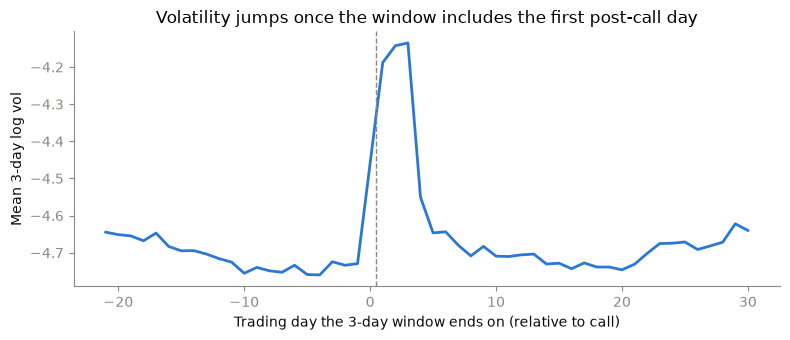

In [ ]:
import matplotlib.pyplot as plt
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#8a8984"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED})

# seeing how volatility changes on rolling 3 day windows
seq_cols = [f"p_past_{k}" for k in range(23, 0, -1)] + [f"p_future_{k}" for k in range(1, 31)]
R = df[seq_cols].to_numpy()                  # rows = calls, cols = day -23 ... day +30
rel = list(range(-23, 0)) + list(range(1, 31))

vols, xs = [], []
for j in range(2, R.shape[1]):               # window = columns j-2, j-1, j
    vols.append(np.log(R[:, j-2:j+1].std(axis=1)).mean())
    xs.append(rel[j])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(xs, vols, color=BLUE, lw=2)
ax.axvline(0.5, color=MUTED, ls="--", lw=1)
ax.set(xlabel="Trading day the 3-day window ends on (relative to call)",
       ylabel="Mean 3-day log vol",
       title="Volatility jumps once the window includes the first post-call day")
plt.tight_layout(); plt.show()

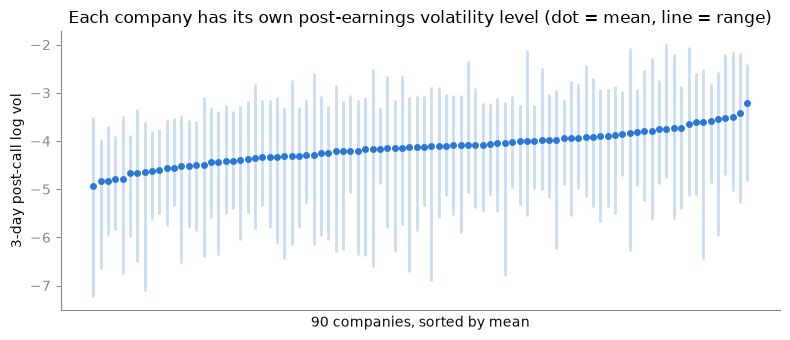

In [ ]:
# each company's typical volatility differs
m = df.groupby("ticker")["y3"].agg(["mean", "min", "max"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.vlines(range(len(m)), m["min"], m["max"], color=BLUE, alpha=0.25, lw=2)
ax.plot(range(len(m)), m["mean"], "o", color=BLUE, ms=4)
ax.set(xticks=[], xlabel="90 companies, sorted by mean", ylabel="3-day post-call log vol",
       title="Each company has its own post-earnings volatility level (dot = mean, line = range)")
plt.tight_layout(); plt.show()

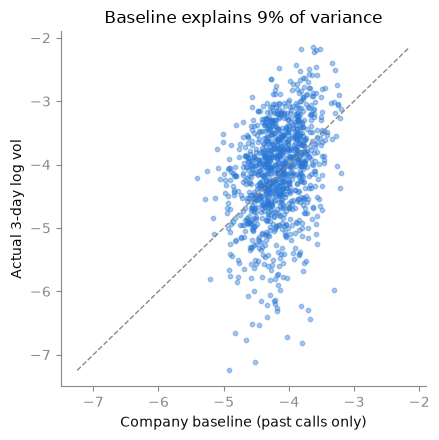

In [ ]:
# how much does the company baseline explain? 
t = df[df["year"] >= 2021]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(t["base3"], t["y3"], s=10, color=BLUE, alpha=0.4)
lo, hi = t[["base3", "y3"]].min().min(), t[["base3", "y3"]].max().max()
ax.plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1)
ax.set(xlabel="Company baseline (past calls only)", ylabel="Actual 3-day log vol",
       title="Baseline explains 9% of variance")
plt.tight_layout(); plt.show()

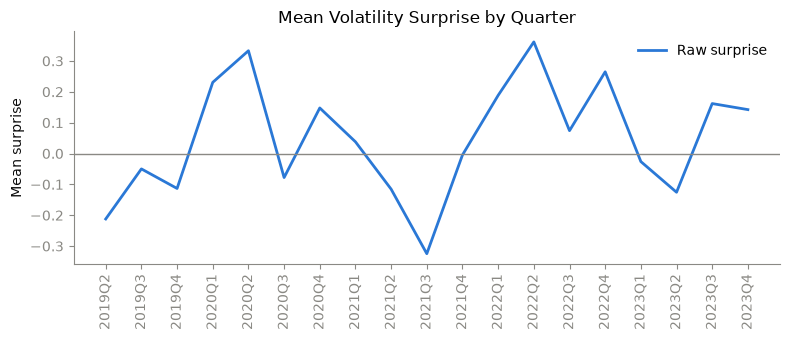

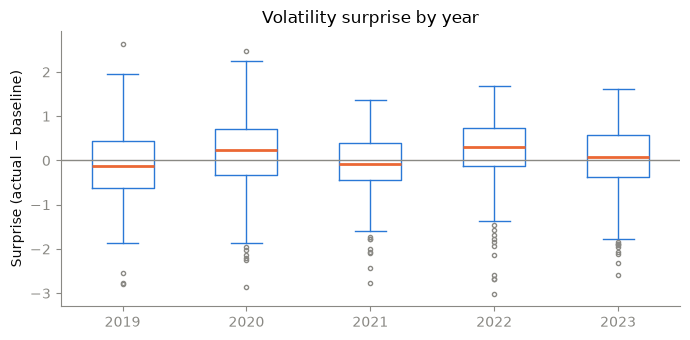

In [ ]:
# surprise distribution by year
yrs = sorted(df["year"].unique())
data = [df.loc[df["year"] == y, "surprise3"].dropna() for y in yrs]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot(data, tick_labels=yrs, widths=0.5, medianprops={"color": ORANGE, "lw": 2},
           boxprops={"color": BLUE}, whiskerprops={"color": BLUE}, capprops={"color": BLUE},
           flierprops={"markeredgecolor": MUTED, "markersize": 3})
ax.axhline(0, color=MUTED, lw=1)
ax.set(ylabel="Surprise (actual − baseline)", title="Volatility surprise by year")
plt.tight_layout(); plt.show()

count     1800.0
mean      9727.0
std       2370.0
min       2203.0
25%       8554.0
50%       9409.0
75%      10536.0
max      27799.0
dtype: float64


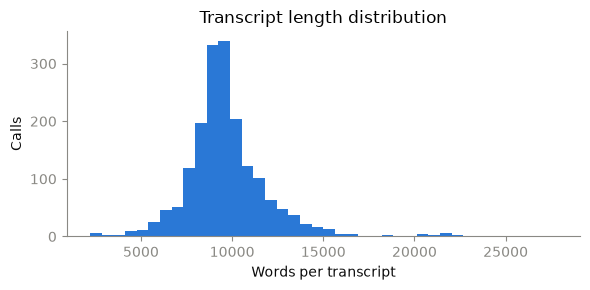

In [ ]:
# transcript length and distribution
lens = pd.Series({k.replace(".txt", ""): len(v.split()) for k, v in dec.items()})
print(lens.describe().round(0))
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(lens, bins=40, color=BLUE)
ax.set(xlabel="Words per transcript", ylabel="Calls",
       title="Transcript length distribution")
plt.tight_layout(); plt.show()

- Event Study: mean log volatility goes from about -4.7 to -4.15 once the window includes the first post call day (roughly 1.7x normal daily volatility). This confirms the timing alignment is correct
- The slow rise from day +20 to day +30 is unexplained
- Company Signature: Company means span about 1.7 log units, but within each company the range is about 3 log units. Individual calls vary more than companies differ from each other. This is why the baseline only explains 9%
- Baseline scatter: baselines are between -5 to -3.2 while actual values are from -7 to -2. The baseline is an average that can't see individual quarters coming.
- Surprise by year: 2020 and 2022 have positive median surprises, 2019 is the widest because its baselines rest on very few past calls

# Data Checks

### Looking at the Shorest and Longest transcripts

In [16]:
print(lens.sort_values().head(5))
print(lens.sort_values().tail(5))

# peek at the shortest one: does it have a Q&A section?
short_id = lens.idxmin()
txt = dec[short_id + ".txt"]
print("has Q&A marker:", "question-and-answer" in txt.lower() or "questions" in txt.lower())
print(txt[-300:])

MCD_2020_Q3_20201109    2203
PSX_2021_Q1_20210430    2387
MPC_2019_Q4_20200129    2537
PSX_2021_Q2_20210803    2610
PSX_2020_Q4_20210129    2729
dtype: int64
PEP_2021_Q2_20210713    22519
PEP_2021_Q3_20211005    23071
PEP_2022_Q2_20220712    24183
PEP_2018_Q4_20190215    25864
PEP_2019_Q2_20190709    27799
dtype: int64
has Q&A marker: False
ur third quarter 2020 earnings call. As Kevin just mentioned, our investor update presentation begins soon at 8:30 am Central Standard Time, and we look forward to connecting with you then.
End of Q&A: This does indeed conclude McDonald’s Corporation investor conference call. You may now disconnect.


- Short calls are real: MCD Q3 2020 was a short call with no Q&A, the text says that most of the discussion happened in a separate investor presentation
- PSX and MPC hold short calls
- The five longest transcripts are all PepsiCo

#### Checking PepsiCo

In [17]:
t = dec["PEP_2019_Q2_20190709.txt"]
print(t.count("Operator:"), "operator turns")
print(t[:200] in t[200:])   # True = the opening text appears again later (duplication)

57 operator turns
True


PepsiCo's transcripts are duplicated

In [18]:
def dup_flag(t, n=200):
    return t[:n] in t[n:]

audit = pd.DataFrame({
    "id": [k.replace(".txt", "") for k in dec],
    "words": [len(v.split()) for v in dec.values()],
    "operator_turns": [v.count("Operator:") for v in dec.values()],
    "duplicated": [dup_flag(v) for v in dec.values()],
})
audit["ticker"] = audit["id"].str.split("_").str[0]

print("duplicated calls:", audit["duplicated"].sum(), "of", len(audit))
print(audit[audit["duplicated"]]["ticker"].value_counts())
print(audit["operator_turns"].describe().round(1))

duplicated calls: 8 of 1800
ticker
PEP    8
Name: count, dtype: int64
count    1800.0
mean       12.7
std         5.4
min         0.0
25%        10.0
50%        12.0
75%        15.0
max        57.0
Name: operator_turns, dtype: float64


- Duplication of 8 PepsiCo Calls

# Early non-neural probe

In [19]:
from sklearn.linear_model import Ridge, LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

d = df.dropna(subset=["base3"]).copy()
d["qkey"] = d["day_earnings"].dt.to_period("Q").astype(str)
d["surprise3_q"] = d["surprise3"] - d.groupby("qkey")["surprise3"].transform("mean")
tr = (d["day_earnings"] < "2022-01-01").values
va = ((d["day_earnings"] >= "2022-01-01") & (d["day_earnings"] < "2023-01-01")).values
te = (d["day_earnings"] >= "2023-01-01").values
print("train/val/test:", tr.sum(), va.sum(), te.sum())

# 1. Baseline table (target: y3, test = 2023)
def mse(a, b): return float(np.mean((np.asarray(a) - np.asarray(b))**2))
y3 = d["y3"].values
rows = {"Global mean (PEV)": np.full(te.sum(), y3[tr | va].mean()),
        "Company baseline (STPEV)": d["base3"].values[te]}
F = d[["base3", "lv3_past_1"]].values       # lv3_past_1 = vol over the 3 days before the call
lr = LinearRegression().fit(F[tr | va], y3[tr | va])
rows["Company baseline + pre-call vol"] = lr.predict(F[te])
for k, p in rows.items():
    print(f"{k:35s} test MSE {mse(p, y3[te]):.3f}")

# 2. Linear probe: embeddings -> quarter-adjusted surprise
def load(name):
    z = np.load(f"../data/Embeddings/openai/{name}.npz", allow_pickle=True)
    return pd.DataFrame(z["embeddings"], index=z["ids"].astype(str))

y = d["surprise3_q"].values
mse0 = mse(0, y[te])   # predicting 0 = company baseline adjusted for the quarter
print(f"\nzero-surprise baseline test MSE {mse0:.3f}")
for name in ["DEC", "DEC2RandomTicker", "DECRandomAll"]:
    X = load(name).loc[d["id"]].values
    best = min(((mse(make_pipeline(StandardScaler(), Ridge(alpha=a)).fit(X[tr], y[tr]).predict(X[va]), y[va]), a)
                for a in [1e1, 1e2, 1e3, 1e4, 1e5]))
    m = make_pipeline(StandardScaler(), Ridge(alpha=best[1])).fit(X[tr | va], y[tr | va])
    p = m.predict(X[te])
    print(f"{name:18s} alpha={best[1]:>8.0f}  test MSE {mse(p, y[te]):.3f}  "
          f"R2 vs baseline {1 - mse(p, y[te]) / mse0:+.3f}  Spearman {spearmanr(p, y[te])[0]:+.3f}")

# 3. Identity check: do transcript embeddings encode the company?
X = load("DEC").loc[d["id"]].values
for target in ["sector", "ticker"]:
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.1))
    clf.fit(X[tr], d[target].values[tr])
    print(f"{target} accuracy on 2023 calls: {clf.score(X[te], d[target].values[te]):.2f}")

train/val/test: 990 360 360
Global mean (PEV)                   test MSE 0.624
Company baseline (STPEV)            test MSE 0.541
Company baseline + pre-call vol     test MSE 0.564

zero-surprise baseline test MSE 0.525
DEC                alpha=  100000  test MSE 0.526  R2 vs baseline -0.001  Spearman +0.039
DEC2RandomTicker   alpha=  100000  test MSE 0.530  R2 vs baseline -0.009  Spearman -0.014
DECRandomAll       alpha=  100000  test MSE 0.527  R2 vs baseline -0.003  Spearman +0.050
sector accuracy on 2023 calls: 0.99
ticker accuracy on 2023 calls: 1.00


*Baseline Table* (using test = 2023)
- The company baseline (.541) beats the global average (.624), company identity matters. This is the core finding of the paper
- Adding pre call volatility made it worse. A regression fit on 2019 - 2022 doesn't transfer to 2023. Need to look into time series applications to adjust this

*Linear Probe: no call specific signal*
- All three embedding sets land at essentially the baseline
- Every run picked alpha = 100,000, the top of the grid. The validation set preferred shrinking the weights toward zero. The validation set preferred shrinking the weights to zero (no surprise)

# Data cleaning and cleaned dataset

In [20]:
print("NaNs in returns/labels:", df[[c for c in df.columns if c.startswith(("p_", "lv"))]].isna().sum().sum())
print("calls per company:", df.groupby("ticker").size().unique())          # expect [20]
print("duplicate ids:", df["id"].duplicated().sum())
print("empty transcripts:", sum(len(v.strip()) == 0 for v in dec.values()))

NaNs in returns/labels: 0
calls per company: [20]
duplicate ids: 0
empty transcripts: 0


In [21]:
def dedupe(t, n=200):
    cut = t.find(t[:n], n)         
    return t if cut == -1 else t[:cut]

text = {k.replace(".txt", ""): v for k, v in dec.items()}
fixed = {k: dedupe(v) for k, v in text.items()}
print("transcripts shortened by dedupe:", sum(len(fixed[k]) < len(text[k]) for k in text))

clean = df[["id", "ticker", "sector", "day_earnings", "beforeAfterMarket",
            "y3", "base3", "surprise3", "lv3_past_1",
            "lv7_future_7", "lv15_future_15", "lv30_future_30"]].copy()
clean["qkey"] = clean["day_earnings"].dt.to_period("Q").astype(str)
clean["surprise3_q"] = clean["surprise3"] - clean.groupby("qkey")["surprise3"].transform("mean")
clean["words"] = clean["id"].map(lambda i: len(fixed[i].split()))
clean["short_call"] = clean["words"] < 4000
clean["split"] = np.select([clean["day_earnings"] < "2022-01-01",
                            clean["day_earnings"] < "2023-01-01"], ["train", "val"], "test")
import os; os.makedirs("../data/processed", exist_ok=True)
clean.to_csv("../data/processed/dec_clean.csv", index=False)      # stays gitignored under data/

transcripts shortened by dedupe: 8


In [22]:
print(clean[["y3", "lv7_future_7", "lv15_future_15", "lv30_future_30", "surprise3", "surprise3_q"]]
      .describe().round(3))
print(clean.groupby("split")[["y3", "surprise3_q"]].agg(["mean", "std", "count"]).round(3))

print(clean.groupby("sector")[["y3", "surprise3"]].mean().sort_values("y3").round(3))
print(clean.groupby("beforeAfterMarket")[["y3", "surprise3"]].agg(["mean", "std"]).round(3))

             y3  lv7_future_7  lv15_future_15  lv30_future_30  surprise3  \
count  1800.000      1800.000        1800.000        1800.000   1710.000   
mean     -4.135        -4.042          -4.077          -4.084      0.047   
std       0.773         0.545           0.479           0.455      0.769   
min      -7.247        -6.262          -5.482          -5.383     -3.015   
25%      -4.597        -4.409          -4.400          -4.401     -0.376   
50%      -4.079        -4.053          -4.095          -4.119      0.096   
75%      -3.603        -3.681          -3.788          -3.827      0.574   
max      -1.986        -2.131          -2.220          -2.387      2.635   

       surprise3_q  
count     1710.000  
mean        -0.000  
std          0.747  
min         -3.279  
25%         -0.408  
50%          0.056  
75%          0.503  
max          2.848  
          y3              surprise3_q             
        mean    std count        mean    std count
split                   

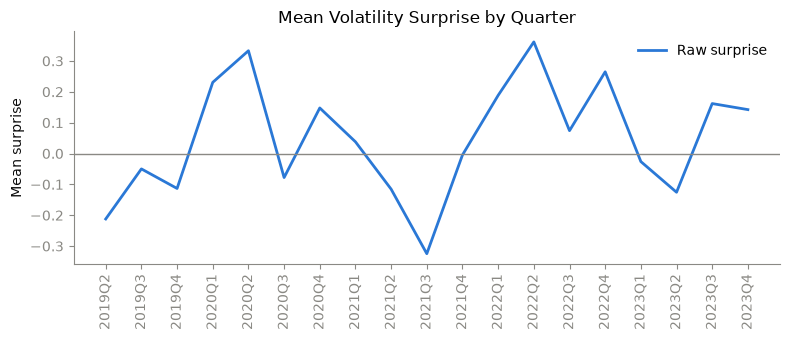

In [34]:
q = clean.groupby("qkey")[["surprise3", "surprise3_q"]].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(q.index, q["surprise3"], color=BLUE, lw=2, label="Raw surprise")
ax.axhline(0, color=MUTED, lw=1)
ax.set(ylabel="Mean surprise", title="Mean Volatility Surprise by Quarter")
ax.tick_params(axis="x", rotation=90); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [24]:
print(clean[["surprise3_q", "words", "lv3_past_1", "base3"]].corr(method="spearman").round(3))

             surprise3_q  words  lv3_past_1  base3
surprise3_q        1.000  0.016       0.025 -0.255
words              0.016  1.000       0.058  0.003
lv3_past_1         0.025  0.058       1.000  0.240
base3             -0.255  0.003       0.240  1.000


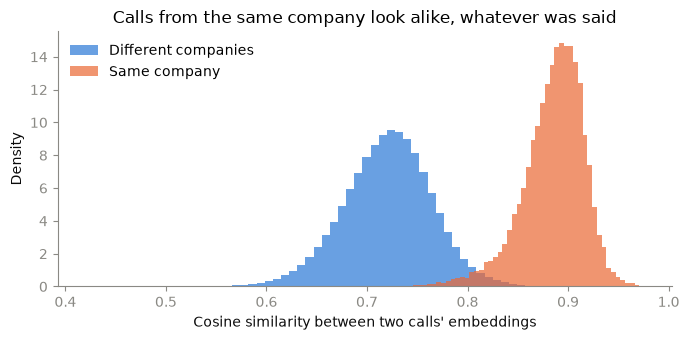

In [25]:
E = load("DEC").loc[clean["id"]].values
E = E / np.linalg.norm(E, axis=1, keepdims=True)
S = E @ E.T
tick = clean["ticker"].to_numpy(dtype=str)
same = tick[:, None] == tick[None, :]
iu = np.triu_indices(len(E), k=1)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(S[iu][~same[iu]], bins=60, density=True, color=BLUE, alpha=0.7, label="Different companies")
ax.hist(S[iu][same[iu]], bins=60, density=True, color=ORANGE, alpha=0.7, label="Same company")
ax.set(xlabel="Cosine similarity between two calls' embeddings", ylabel="Density",
       title="Calls from the same company look alike, whatever was said")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

# Outliers

In [26]:
ext = clean.dropna(subset=["surprise3_q"]).sort_values("surprise3_q")
print(ext[["id", "sector", "y3", "base3", "surprise3_q", "words"]].head(5))   # calmer than usual
print(ext[["id", "sector", "y3", "base3", "surprise3_q", "words"]].tail(5))   # more volatile than usual
for i in [ext["id"].iloc[0], ext["id"].iloc[-1]]:
    t = fixed[i]; mid = len(t) // 2
    print(f"\n--- {i} (middle of call) ---\n{t[mid:mid+500]}")

                         id                  sector        y3     base3  \
1755   WFC_2022_Q3_20221014      Financial Services -6.809466 -3.794959   
712    FCX_2021_Q4_20220126         Basic Materials -5.975782 -3.301744   
215   AVGO_2022_Q4_20221208              Technology -6.292346 -3.706889   
1506     T_2020_Q2_20200723  Communication Services -6.907019 -4.050456   
151    AMD_2021_Q3_20211026              Technology -6.440911 -3.670623   

      surprise3_q  words  
1755    -3.279237  10979  
712     -2.862516  10301  
215     -2.850187   6709  
1506    -2.778668   9539  
151     -2.765601   7685  
                         id              sector        y3     base3  \
1184  ORCL_2020_Q3_20200312          Technology -2.041355 -4.243442   
1345   PSX_2020_Q1_20200501              Energy -2.499105 -4.982101   
1181  ORCL_2019_Q4_20190619          Technology -3.194296 -5.138634   
446    CRM_2021_Q2_20200825          Technology -2.197441 -4.355494   
841    JPM_2019_Q1_20190412  Fin

In [27]:
for i in ["WFC_2022_Q3_20221014", "T_2020_Q2_20200723"]:
    r = df.loc[df["id"] == i, ["p_future_1", "p_future_2", "p_future_3"]].round(4)
    print(i, r.values.ravel())

WFC_2022_Q3_20221014 [0.0186 0.0183 0.0161]
T_2020_Q2_20200723 [-0.0086 -0.011  -0.0095]


In [28]:
F3 = df[["p_future_1", "p_future_2", "p_future_3"]].to_numpy()
F7 = df[[f"p_future_{i}" for i in range(1, 8)]].to_numpy()
df["rv3"] = np.log(np.sqrt((F3**2).mean(axis=1)))     # root-mean-square, no demeaning
df["rv7"] = np.log(np.sqrt((F7**2).mean(axis=1)))

print(df.loc[df["id"].isin(["WFC_2022_Q3_20221014", "T_2020_Q2_20200723"]),
             ["id", "y3", "rv3"]].round(3))
print(df[["y3", "rv3", "lv7_future_7", "rv7"]].describe().round(3))
print("corr y3 vs rv3:", df[["y3", "rv3"]].corr().iloc[0, 1].round(3))

                        id     y3    rv3
1506    T_2020_Q2_20200723 -6.907 -4.630
1755  WFC_2022_Q3_20221014 -6.809 -4.032
             y3       rv3  lv7_future_7       rv7
count  1800.000  1800.000      1800.000  1800.000
mean     -4.135    -3.849        -4.042    -3.957
std       0.773     0.675         0.545     0.532
min      -7.247    -7.103        -6.262    -6.108
25%      -4.597    -4.290        -4.409    -4.306
50%      -4.079    -3.826        -4.053    -3.967
75%      -3.603    -3.395        -3.681    -3.598
max      -1.986    -1.863        -2.131    -2.039
corr y3 vs rv3: 0.887


/var/folders/8s/x70pwprd6p34_2y8q6xy3mk80000gn/T/ipykernel_95150/2323686486.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rv3"] = np.log(np.sqrt((F3**2).mean(axis=1)))     # root-mean-square, no demeaning
/var/folders/8s/x70pwprd6p34_2y8q6xy3mk80000gn/T/ipykernel_95150/2323686486.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rv7"] = np.log(np.sqrt((F7**2).mean(axis=1)))


- Low side outliers: WFC rose 5.4% over three days, but since the conventional label scores measures spread around the window mean, and all 3 days rose by roughly the same, it was scored as the calmest call.
- High side outliers: Some of the high side outliers are covid or oil crash shocks that calendar quarter adjustment can't remove because they started mid quarter. 

# Summary 

- No missing values, 20 calls per company, no duplicate IDs, no empty transcripts. 
- Longer windows are smoother; the earnings shock gets diluted
- The validation year (2022) is more volatile
- After close calls are more volatile than before open calls. 